# ── 0️⃣ COMPRÉHENSION MÉTIER — CLASSIFICATION (EDUCATION - CRISP-ML(Q)) ──

## 0.1 Objectif Métier (Business Understanding)
> **Alignement MLOps** : Cette cellule présente les exigences de l'étape 1 de la méthodologie **CRISP-ML(Q)** pour le dataset `test_cameroun_business`.

### 🎯 Objectif Business
Exploration de données, identification de patterns structurels et modélisation prédictive de baseline.

### 💰 Matrice d'Impact Économique (Coûts & Gains)
| Résultat | Action Métier | Impact |
|---|---|---|
| **Correct** | Décision alignée | + Efficacité opérationnelle |
| **Erreur** | Mauvais alignement | - Perte de temps / Coût d'opportunité |

### 📊 Métriques de Succès Métier
Robustesse statistique, scores supérieurs au benchmark aléatoire.

## 0.2 Contraintes, Réglementation & Risques
*   **⚙️ Contraintes Techniques** : Données structurées, Interprétabilité de base
*   **⚖️ Cadre Réglementaire & Éthique** : RGPD (anonymisation et sécurité des données).
*   **⚠️ Pièges Fréquents à Éviter** : Sur-apprentissage sur les données historiques, non-validation sur données hors-échantillon (OOD).

---
> 📌 *La colonne cible validée pour cette modélisation est : `target_class`.*
> 🔒 *Les seuils d'alertes et coûts associés sont paramétrables dans `config/metrics.yaml`.*


# ⚙️ Étape 0 — Setup, Chargement & Split (CRISP-ML(Q)) (Cellule 1)

## 0.2 Configuration et Initialisation (Setup & Config)

In [ ]:
# ── Magics de rechargement automatique
# Garantit que toute modification dans les modules .py externes est prise en compte instantanément.
%load_ext autoreload
%autoreload 2

import os
import sys
import glob
import time
import warnings
import random
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, RepeatedKFold, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, r2_score, mean_absolute_error, mean_squared_error
import mlflow

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# ── Reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Système de Traçage
import logging
logging.basicConfig(level=logging.INFO, format='[%(asctime)s] %(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

def log_section(section_name):
    logger.info(f"{'='*60}")
    logger.info(f"DÉBUT SECTION : {section_name}")
    logger.info(f"{'='*60}")


# ── Variables d'environnement / Paramètres de l'Agent IA (injectés)
FILE_PATH      = r"C:/Users/HP/cam_data_sov_solutions newversion/dataset_automator/workspace/outputs/test_cameroun_business/cleaned_e8714a29_20260718_084003.csv"
TARGET_COL     = "target_class"
DATASET_NAME   = "test_cameroun_business"
TYPE_TACHE     = "classification"
IS_TS          = TYPE_TACHE in ["timeseries", "time_series"]

BASE_DIR       = Path(os.getcwd()) / "outputs" / DATASET_NAME
OUTPUT_DIR     = BASE_DIR
RAW_DIR        = BASE_DIR / "data" / "raw"
PROCESSED_DIR  = BASE_DIR / "data" / "processed"
INTERIM_DIR    = BASE_DIR / "data" / "interim"
MODELS_DIR     = BASE_DIR / "models"
NB_DIR         = BASE_DIR / "notebooks"
NOM_BASE       = DATASET_NAME

# ✅ Création de l'arborescence MLOps stricte
for d in [OUTPUT_DIR, RAW_DIR, PROCESSED_DIR, INTERIM_DIR, MODELS_DIR, NB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Initialisation MLflow
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
mlflow_dir = OUTPUT_DIR / 'mlruns'
mlflow.set_tracking_uri(mlflow_dir.as_uri())
mlflow.set_experiment(f"Exp_test_cameroun_business")

print("🔍 Vérification de l'environnement...")
print(f"   MLflow exp : Exp_test_cameroun_business")

# Sauvegarde d'un dataset d'entraînement de secours si absent
if not os.path.isfile(FILE_PATH):
    print("⚠️ Fichier introuvable. Génération d'un dataset synthétique supervisé...")
    from sklearn.datasets import make_classification, make_regression
    if TYPE_TACHE == "classification" or TYPE_TACHE == "unsupervised":
        X_arr, y_arr = make_classification(n_samples=1000, n_features=10, n_informative=8, random_state=SEED)
        cols = [f"feature_{i}" for i in range(10)]
        df_fake = pd.DataFrame(X_arr, columns=cols)
        df_fake[TARGET_COL] = y_arr
    else:
        X_arr, y_arr = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=SEED)
        cols = [f"feature_{i}" for i in range(10)]
        df_fake = pd.DataFrame(X_arr, columns=cols)
        df_fake[TARGET_COL] = y_arr
    FILE_PATH = str(OUTPUT_DIR / "synthetic_supervised.csv")
    df_fake.to_csv(FILE_PATH, index=False)

# Chargement robuste
ext = Path(FILE_PATH).suffix.lower()
df_raw = pd.read_excel(FILE_PATH) if ext in ['.xlsx', '.xls'] else pd.read_csv(FILE_PATH)
df = df_raw.copy()

# Traitement des colonnes temporelles
date_cols_found = []
for col in df.columns:
    if any(k in col.lower() for k in ['date', 'time', 'timestamp']):
        try:
            df[col] = pd.to_datetime(df[col])
            date_cols_found.append(col)
        except:
            pass

if date_cols_found:
    df = df.set_index(date_cols_found[0]).sort_index()
    print(f"✅ Indexation temporelle sur : {date_cols_found[0]}")

# Séparation des features et de la cible
if TYPE_TACHE == "unsupervised" or not TARGET_COL or TARGET_COL not in df.columns:
    X = df.copy()
    y = None
    print("✅ Mode non-supervisé / Clustering actif.")
else:
    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL]

if TYPE_TACHE == "classification" and y is not None and (y.dtype == "object" or y.dtype.name == "category"):
    le = LabelEncoder()
    y = pd.Series(le.fit_transform(y), index=y.index)
    print("✅ Cible catégorielle encodée avec LabelEncoder.")

# Split Anti-Leakage (Temporel si DatetimeIndex, sinon aléatoire)
if isinstance(df.index, pd.DatetimeIndex):
    split = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = (y.iloc[:split], y.iloc[split:]) if y is not None else (None, None)
    print("✅ Split temporel (Chronologique) effectué.")
else:
    strat = y if TYPE_TACHE == "classification" else None
    if y is not None:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=SEED, stratify=strat
        )
    else:
        X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
        y_train, y_test = None, None
    print("✅ Split aléatoire effectué.")

FEATURE_NAMES = list(X.columns)
print(f"✅ Split terminé. Train: {len(X_train)} | Test: {len(X_test)}")

## 🤖 Stratégie de Nettoyage Dynamique (Agent IA)

L'agent a défini et exécuté la stratégie de nettoyage suivante basée sur les règles métiers du graphe de connaissances Neo4j (Graph RAG) :

| Variable / Colonne | Action Technique | Justification Métier / RAG |
| :--- | :--- | :--- |
| **montant_fcfa** | `clean_fcfa` | Traduction en euros |


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def clean_fcfa_currency(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.replace(r'(?i)(?:fcfa|xaf|xof|f|\s|,)', '', regex=True)
    return pd.to_numeric(cleaned, errors='coerce')

# Nettoyage des partitions sans fuite (Statistiques calculées STRICTEMENT sur le Train set)
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

# 1. Suppression des colonnes ID à haute cardinalité
high_card_cols = [col for col in X_train_clean.columns if X_train_clean[col].dtype == 'object' and X_train_clean[col].nunique() > 50]
if high_card_cols:
    X_train_clean = X_train_clean.drop(columns=high_card_cols)
    X_test_clean = X_test_clean.drop(columns=[c for c in high_card_cols if c in X_test_clean.columns])

# Étape : clean_fcfa sur 'montant_fcfa'
# Raison : Traduction en euros
if 'montant_fcfa' in X_train_clean.columns:
    if X_train_clean['montant_fcfa'].dtype == 'object' or X_train_clean['montant_fcfa'].dtype.name == 'category':
        X_train_clean['montant_fcfa'] = clean_fcfa_currency(X_train_clean['montant_fcfa'])
        if 'montant_fcfa' in X_test_clean.columns:
            X_test_clean['montant_fcfa'] = clean_fcfa_currency(X_test_clean['montant_fcfa'])

# partitions nettoyées prêtes pour le preprocessing.
train_df_clean = X_train_clean.copy() # Utilisé pour les diagnostics visuels suivants
if 'X_train_clean' in globals():
    display(X_train_clean.head())

## 0.3 Validation du Contrat de Données (Data Quality Contracts)
> **Objectif MLOps** : Valider la conformité des données par rapport aux contraintes sémantiques issues du Knowledge Graph.

In [ ]:
# ── ASSERTIONS DE QUALITÉ DE DONNÉES (DATA CONTRACTS)

# ── Validation du Contrat de Données avec Pandera (Lazy Evaluation)
import pandera as pa
from pandera.pandas import DataFrameSchema, Column, Check

schema = DataFrameSchema(
    columns={
        "tel": Column(str, checks=Check.str_matches(r"^(\\+237|237)?6[2-9][0-9]{7}$"), nullable=True),
        "montant_fcfa": Column(float, checks=Check.greater_than_or_equal_to(0), nullable=True),
    }
)

try:
    schema.validate(df, lazy=True)
    print("✅ Validation Pandera réussie : Le schéma de données est strictement respecté.")
except pa.errors.SchemaErrors as err:
    print("❌ Échec de la validation du contrat de données Pandera.")
    # Affichage des failure_cases
    import traceback
    display(err.failure_cases)
    # Sauvegarde des cas non conformes en quarantaine (Quarantine)
    quarantine_path = INTERIM_DIR / "quarantine_errors.csv"
    err.failure_cases.to_csv(quarantine_path, index=False)
    print(f"⚠️ Fichier de quarantaine des erreurs généré dans : {quarantine_path}")


# 🔍 Étape 1 — Analyse Exploratoire Senior (EDA) & Diagnostic de Qualité

> 💡 **Note MLOps** : Cette analyse exploratoire s'exécute sur le dataset pré-nettoyé par l'Orchestrateur MLOps. L'objectif de cette étape est de valider scientifiquement la conformité des transformations (imputations, encodages) appliquées par les agents avant de lancer l'entraînement des modèles. Un diagnostic sans valeurs manquantes (0% NaNs) valide le succès de la phase de nettoyage.

## 1.1 Diagnostic du Dataset : Valeurs Manquantes (Cellule 3)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Fallback si train_df_clean n'est pas défini (ex: exécution hors orchestrateur)
if 'train_df_clean' not in globals():
    train_df_clean = df.copy() if 'df' in globals() else df_raw.copy()

print("📊 1. Diagnostic des Valeurs Manquantes")
print("=" * 60)

missing_pct = train_df_clean.isnull().mean() * 100
missing_cols = missing_pct[missing_pct > 0].sort_values(ascending=False)

if not missing_cols.empty:
    print(f"⚠️ {len(missing_cols)} variables ont des valeurs manquantes.")
    for col, pct in missing_cols.items():
        print(f"   - {col}: {pct:.1f}%")
    
    # Diagnostic Senior : Analyse de la nature du manque
    print("\n🔬 Analyse Statistique du Manque (MCAR vs MNAR) :")
    for col in missing_cols.index[:3]:
        print(f"   🔎 Variable: {col}")
        indicator = train_df_clean[col].isnull().astype(int)
        numeric_cols = train_df_clean.select_dtypes(include=[np.number]).columns.drop([col], errors='ignore')
        if not numeric_cols.empty:
            corr_with_missing = train_df_clean[numeric_cols].corrwith(indicator).abs().sort_values(ascending=False).head(2)
            if corr_with_missing.max() > 0.2:
                print(f"      🚨 Suspicion de MAR : Corrélation détectée avec {corr_with_missing.index.tolist()}")
            else:
                print("      ✅ Probablement MCAR ou MNAR (pas de corrélation évidente avec les autres variables)")
else:
    print("✅ Aucune valeur manquante détectée dans le dataset nettoyé.")

# Recherche du fichier brut d'origine pour comparer les manques
try:
    raw_path_possibilities = [
        os.path.join("..", "..", "data", f"test_cameroun_business.csv"),
        os.path.join("..", "..", "data", "raw", f"test_cameroun_business.csv"),
        os.path.join("C:/Users/HP/cam_data_sov_solutions newversion/data", f"test_cameroun_business.csv"),
    ]
    raw_file = None
    for p in raw_path_possibilities:
        if os.path.exists(p):
            raw_file = p
            break
            
    if raw_file:
        df_raw_original = pd.read_csv(raw_file)
        print("\n🔄 Comparaison avec les données brutes d'origine :")
        print(f"   - Fichier brut d'origine : {os.path.basename(raw_file)}")
        print(f"   - Lignes : {len(df_raw_original)} | Colonnes : {len(df_raw_original.columns)}")
        
        # Compter les NaNs d'origine
        nans_original = df_raw_original.isnull().sum()
        total_nans = nans_original.sum()
        if total_nans > 0:
            print(f"   - Total de valeurs manquantes réparées par l'orchestrateur : {total_nans}")
            for col, count in nans_original[nans_original > 0].items():
                print(f"     * Variable '{col}' : {count} NaNs réparés ({count/len(df_raw_original)*100:.1f}%)")
        else:
            print("   - Le fichier brut d'origine ne contenait aucune valeur manquante.")
except Exception as raw_err:
    pass

# Visualisation des manques (Matrix)
if not missing_cols.empty:
    try:
        import missingno as msno
        plt.figure(figsize=(10, 4))
        msno.matrix(train_df_clean, sparkline=False, color=(0.1, 0.4, 0.6))
        plt.title("🔥 Matrice de nullité (Patterns de manques)")
        plt.show()
    except Exception as e:
        print(f"⚠️ Impossible de tracer la matrice de nullité : {e}")

## 1.2 Diagnostic de Structure & Variance (Cellule 4)

In [ ]:
print("\n📊 2. Diagnostic de Variance & Structure")
print("=" * 60)

# Les variables à variance nulle ou quasi-nulle
variances = train_df_clean.var(numeric_only=True).sort_values()
low_variance_cols = variances[variances < 0.01].index.tolist()

if low_variance_cols:
    print(f"⚠️ Variables à faible variance détectées : {low_variance_cols}")
    print("👉 Conseil : Ces variables pourraient être supprimées car elles n'apportent pas de pouvoir discriminant.")
else:
    print("✅ Toutes les variables numériques présentent une variance significative.")

# ── Analyse des Corrélations ──────────────────────────────────────
print("\n🔗 3. Analyse des Corrélations (Multicolinéarité)")
corr_matrix = train_df_clean.corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

if to_drop:
    print(f"⚠️ Variables fortement corrélées (>0.95) : {to_drop}")
else:
    print("✅ Pas de multicolinéarité extrême détectée.")

if TYPE_TACHE == "unsupervised":
    print("\n⚠️ AVERTISSEMENT CLUSTERING :")
    print("👉 Les algorithmes basés sur les distances sont extrêmement sensibles aux échelles des variables.")
    print("👉 Un scaling (ex: RobustScaler / StandardScaler) est OBLIGATOIRE avant l'entraînement.")

## 1.3 Analyse Univariée (Cellule 5)

In [ ]:
print("\n📊 2. Analyse Univariée & Outliers")
print("-" * 60)

num_cols = train_df_clean.select_dtypes(include=[np.number]).columns.tolist()
top_num = num_cols[:min(6, len(num_cols))]

if top_num:
    fig, axes = plt.subplots(len(top_num), 2, figsize=(15, 4 * len(top_num)))
    if len(top_num) == 1:
        axes = axes.reshape(1, 2)
    for i, col in enumerate(top_num):
        # Distribution & Skewness
        sns.histplot(train_df_clean[col], kde=True, ax=axes[i, 0], color='steelblue')
        skew = train_df_clean[col].skew()
        axes[i, 0].set_title(f"Distribution de {col} (Skewness: {skew:.2f})")
        
        # Boxplot pour Outliers
        sns.boxplot(x=train_df_clean[col], ax=axes[i, 1], color='coral')
        axes[i, 1].set_title(f"Boxplot de {col} (Valeurs aberrantes)")
        
        # Calcul d'interprétation dynamique
        q1 = train_df_clean[col].quantile(0.25)
        q3 = train_df_clean[col].quantile(0.75)
        iqr = q3 - q1
        outliers = train_df_clean[(train_df_clean[col] < q1 - 1.5 * iqr) | (train_df_clean[col] > q3 + 1.5 * iqr)]
        outliers_pct = (len(outliers) / len(train_df_clean)) * 100
        
        print(f"🔎 Variable '{col}' :")
        print(f"   - Asymétrie (Skewness) : {skew:.2f} ({'Forte asymétrie' if abs(skew) > 1 else 'Distribution équilibrée'})")
        print(f"   - Valeurs aberrantes (Outliers) : {outliers_pct:.1f}% de lignes concernées")
        if outliers_pct > 5:
            print(f"     💡 Recommandation : Les outliers (>5%) suggèrent d'utiliser des modèles robustes (arbre de décision) ou un traitement spécifique.")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, '01_univariate_analysis.png'))
    plt.show()
else:
    print("⚠️ Aucune variable numérique à analyser.")

## 1.4 Corrélations Avancées & VIF (Cellule 6)

In [ ]:
print("\n📊 3. Étude des Corrélations (Pearson/Spearman)")
print("-" * 60)

try:
    num_df = train_df_clean.select_dtypes(include=np.number)
    
    if num_df.shape[1] <= 1:
        print("💡 Peu de variables numériques. Encodage temporaire des variables catégorielles.")
        df_encoded = train_df_clean.copy()
        cat_cols = df_encoded.select_dtypes(include=['object', 'category']).columns
        for col in cat_cols:
            df_encoded[col] = df_encoded[col].astype('category').cat.codes
        corr_p = df_encoded.corr(method='pearson')
        corr_s = df_encoded.corr(method='spearman')
        is_mixed = True
    else:
        corr_p = num_df.corr(method='pearson')
        corr_s = num_df.corr(method='spearman')
        is_mixed = False
        
    # Détection de Multicolinéarité (VIF)
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X_vif = train_df_clean.select_dtypes(include=[np.number]).dropna()
    if X_vif.shape[1] > 1:
        vif_data = pd.DataFrame()
        vif_data["feature"] = X_vif.columns
        vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
        high_vif = vif_data[vif_data["VIF"] > 10]
        if not high_vif.empty:
            print("⚠️ Multicolinéarité détectée (VIF > 10) :")
            print(high_vif)
            print("\n🔎 Interprétation Multicollinéarité :")
            print(f"   La multicolinéarité est critique pour les variables: {high_vif['feature'].tolist()}.")
            print("   💡 Recommandation : Ces variables redondantes doivent être réduites (PCA/UMAP) ou certaines exclues pour éviter d'altérer la stabilité des coefficients et l'interprétation SHAP.")
    
    if corr_p.shape[1] <= 1:
        print("✅ Pas assez de variables pour tracer une matrice de corrélation.")
    else:
        plt.figure(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr_p, dtype=bool))
        sns.heatmap(corr_p, mask=mask, annot=True, cmap='coolwarm', fmt='.2f')
        title_suffix = " (avec variables catégorielles encodées)" if is_mixed else ""
        plt.title(f"🔥 Matrice de Corrélation de Pearson{title_suffix}")
        plt.show()
except Exception as e:
    print(f"⚠️ Erreur corrélation/VIF : {e}")

## 1.5 Analyse Éthique & Biais (Cellule 7)

In [ ]:
print("\n📊 4. Analyse des Biais & Déséquilibres Éthiques")
print("-" * 60)

cat_cols = train_df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f"Variables catégorielles analysées : {cat_cols[:5]}")
    for col in cat_cols[:3]:
        counts = train_df_clean[col].value_counts(normalize=True)
        imbalance = counts.max() / counts.min() if counts.min() > 0 else np.inf
        if imbalance > 10:
            print(f"⚠️ Déséquilibre fort sur '{col}' : Ratio max/min = {imbalance:.1f}")
            print(counts.head())
else:
    print("✅ Aucune variable catégorielle évidente pour l'étude des biais.")

## 1.6 Analyse de la Cible (Cellule 8)

In [ ]:
if TARGET_COL in train_df_clean.columns:
    print(f"\n🎯 Analyse de la cible : target_class")
    if IS_TS:
        # Time Series Target
        plt.figure(figsize=(14, 5))
        train_df_clean[TARGET_COL].plot(lw=1.5, color='steelblue')
        plt.title(f"📈 Évolution temporelle de target_class")
        plt.show()
    elif TYPE_TACHE == "regression" or (train_df_clean[TARGET_COL].dtype in [np.float64, np.int64] and TYPE_TACHE != "classification"):
        # Regression Target Analysis
        from scipy import stats
        
        target_series = train_df_clean[TARGET_COL].dropna()
        skewness = target_series.skew()
        kurt = target_series.kurtosis()
        
        print(f"   Moyenne  : {target_series.mean():.2f}")
        print(f"   Médiane  : {target_series.median():.2f}")
        print(f"   Skewness (Asymétrie) : {skewness:.3f}")
        print(f"   Kurtosis : {kurt:.3f}")
        
        if abs(skewness) > 1:
            print("   ⚠️ Variable cible asymétrique. Une transformation log ou Box-Cox sera appliquée dans le preprocessing.")
            
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. Histogramme + KDE
        sns.histplot(target_series, kde=True, ax=axes[0], color='teal')
        axes[0].set_title(f'Distribution de target_class')
        
        # 2. Boxplot
        sns.boxplot(x=target_series, ax=axes[1], color='teal')
        axes[1].set_title(f'Boxplot de target_class')
        
        # 3. Q-Q Plot
        stats.probplot(target_series, dist="norm", plot=axes[2])
        axes[2].set_title('Normal Q-Q Plot')
        
        plt.tight_layout()
        plt.show()
    else:
        # Classification Target
        print(f"Distribution des classes :")
        counts = train_df_clean[TARGET_COL].value_counts()
        pct = train_df_clean[TARGET_COL].value_counts(normalize=True) * 100
        for val in counts.index:
            print(f"   - Classe '{val}' : {counts[val]} ({pct[val]:.1f}%)")
            
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        train_df_clean[TARGET_COL].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
        axes[0].set_title('Effectifs par classe')
        train_df_clean[TARGET_COL].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
        axes[1].set_title('Proportion des classes')
        plt.tight_layout()
        plt.show()
else:
    print("\n🎯 Mode non-supervisé / Clustering actif :")
    print("   -> Aucune variable cible (TARGET_COL) dans ce dataset.")
    print(f"   -> Nombre de variables descriptives à segmenter : {train_df_clean.shape[1]}")

# ── 1.6 Outils One-Line EDA (Interactive & High-Density) ───────────────
print("\n📊 6. Génération de Rapports d'EDA Automatique (Sweetviz / PyGwalker)")
print("=" * 60)

try:
    import sweetviz as sv
    # Génération d'un rapport interactif Sweetviz
    print("⚙️ Génération du rapport comparatif Sweetviz...")
    if 'X_train' in globals() and 'X_test' in globals():
        train_df_sv = X_train.copy()
        test_df_sv = X_test.copy()
        if TARGET_COL and TARGET_COL in df.columns:
            train_df_sv[TARGET_COL] = y_train
            test_df_sv[TARGET_COL] = y_test
        my_report = sv.compare([train_df_sv, "Train Set"], [test_df_sv, "Test Set"], target_feat=TARGET_COL if TARGET_COL else None)
    else:
        my_report = sv.analyze(train_df_clean, target_feat=TARGET_COL if TARGET_COL else None)
    
    # Sauvegarde du rapport HTML
    report_file = BASE_DIR / "EDA_Sweetviz_Report.html"
    my_report.show_html(filepath=str(report_file), open_browser=False)
    print(f"✅ Rapport Sweetviz généré avec succès à l'emplacement : {report_file}")
except Exception as e_sv:
    print(f"⚠️ Impossible de générer le rapport Sweetviz : {e_sv}")

try:
    import pygwalker as pyg
    print("\n📊 Initialisation de l'interface interactive Pygwalker (style Tableau)...")
    # Retourne un composant interactif dans les notebooks Jupyter
    walker = pyg.walk(train_df_clean)
except Exception as e_pyg:
    print(f"⚠️ PyGwalker non disponible ou erreur d'initialisation : {e_pyg}")

print("\n✅ EDA SENIOR ET VISUALISATION INTERACTIVE TERMINÉES")

,StartLine:291,TargetContent:

```

# 🔧 Étape 2 — Prétraitement & Feature Engineering Senior

## Objectif
Mise en place d'un pipeline **Scikit-Learn** de niveau industriel :
- **Nettoyage Automatique** : Suppression des doublons et placeholders ("?").
- **Capping (Winsorization)** : Plafonnement des valeurs aberrantes (outliers) pour protéger les modèles.
- **Missing Indicator** : Capture de l'information sur l'absence de données (MNAR).
- **IterativeImputer (MICE)** : Imputation statistique avancée.
- **Feature Generation** : Création de variables métier et transformations.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose  import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer)
from sklearn.impute import SimpleImputer
import time

# ── 2.1 Feature Generation (Métier) ───────────────────────────────────
print("🧪 1. Feature Generation & Transformations")
print("-" * 60)

def engineering_func(X):
    X_out = X.copy()
    # Exemple de création de variables (à adapter selon le domaine)
    num_cols = X_out.select_dtypes(include=[np.number]).columns
    if len(num_cols) >= 2:
        # Création d'un ratio simple entre les deux premières variables numériques
        X_out['feat_ratio_1_2'] = X_out[num_cols[0]] / (X_out[num_cols[1]] + 1e-6)
    
    # Transformations Log pour réduire le skewness
    for col in num_cols:
        if X_out[col].skew() > 1:
            X_out[f'log_{col}'] = np.log1p(X_out[col].clip(lower=0))
            
    return X_out

feature_eng = FunctionTransformer(engineering_func)
print("✅ Fonctions de transformation métier prêtes.")

# ── 2.2 Configuration des Imputers (Senior) ───────────────────────────
try:
    from sklearn.experimental import enable_iterative_imputer
    from sklearn.impute import IterativeImputer
    # add_indicator=True est CRUCIAL pour les données MNAR
    IMPUTER_NUM = IterativeImputer(max_iter=10, random_state=42, add_indicator=True)
    print("🧬 Imputation Numérique : IterativeImputer + MissingIndicator")
except ImportError:
    IMPUTER_NUM = SimpleImputer(strategy='median', add_indicator=True)
    print("📊 Imputation Numérique : SimpleImputer (médiane) + MissingIndicator")

IMPUTER_CAT = SimpleImputer(strategy='most_frequent', add_indicator=True)

# ── 2.3 Détection de la Multicolinéarité (VIF) ─────────────────────────
print("\n🔬 3. Analyse de la Multicolinéarité (VIF)")
print("-" * 60)

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant
    
    def detect_multicollinearity(X_df):
        # Ne garder que les colonnes numériques et éliminer les NaN pour le VIF
        X_num = X_df.select_dtypes(include=[np.number]).dropna()
        if X_num.empty or X_num.shape[1] <= 1:
            print("   ℹ️ Nombre insuffisant de variables numériques pour le VIF.")
            return None
        
        # Ajouter une constante (intercepte) indispensable pour éviter les erreurs de calcul du VIF
        X_with_const = add_constant(X_num)
        
        vif_data = pd.DataFrame()
        vif_data["Variable"] = X_with_const.columns
        vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
                           for i in range(X_with_const.shape[1])]
        
        # Filtrer la constante artificielle et trier par ordre décroissant
        vif_data = vif_data[vif_data["Variable"] != "const"].sort_values(by="VIF", ascending=False)
        return vif_data

    X_train_inp = X_train_clean if 'X_train_clean' in globals() else X_train
    vif_results = detect_multicollinearity(X_train_inp)
    if vif_results is not None:
        display(vif_results)
        # Signaler les variables hautement colinéaires (VIF > 5)
        high_vif = vif_results[vif_results["VIF"] > 5]
        if not high_vif.empty:
            print(f"   ⚠️ ALERTE MULTICOLINÉARITÉ : {len(high_vif)} variable(s) ont un VIF > 5 !")
            for _, row in high_vif.iterrows():
                print(f"     - {row['Variable']} (VIF: {row['VIF']:.2f})")
            print("   👉 Recommandation : Envisager d'éliminer la variable au VIF le plus élevé ou de faire du Feature Engineering (ratios, PCA).")
        else:
            print("   ✅ Aucune multicolinéarité significative détectée (tous les VIF <= 5).")
except Exception as e_vif:
    print(f"   ⚠️ Impossible de calculer le VIF : {e_vif}")

## Construction du Pipeline

In [ ]:
# Identifier les types de colonnes (sur les données d'entrée nettoyées)
X_train_inp = X_train_clean if 'X_train_clean' in globals() else X_train
num_features = X_train_inp.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train_inp.select_dtypes(include=['object', 'category']).columns.tolist()

# ── Pipeline Numérique ────────────────────────────────────────────────
from sklearn.decomposition import PCA
USE_PCA = False

if USE_PCA:
    print("✨ PCA activée dans le pipeline (95% de variance conservée)")
    numeric_pipeline = Pipeline([
        ('imputer', IMPUTER_NUM),
        ('scaler',  RobustScaler()),
        ('pca', PCA(n_components=0.95, random_state=42))
    ])
else:
    numeric_pipeline = Pipeline([
        ('imputer', IMPUTER_NUM),
        ('scaler',  RobustScaler()),
    ])

# ── Pipeline Catégoriel ──────────────────────────────────────────────
categorical_pipeline = Pipeline([
    ('imputer', IMPUTER_CAT),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ── ColumnTransformer ─────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_features),
        ('cat', categorical_pipeline, cat_features),
    ],
    remainder='drop'
)

# ── Pipeline Global (Engineering + Preprocessing) ─────────────────────
full_pipeline = Pipeline([
    ('engineering', feature_eng),
    ('preprocessing', preprocessor)
])

print("\n⚙️  Fitting du pipeline complet...")
t0 = time.time()
X_train_inp = X_train_clean if 'X_train_clean' in globals() else X_train
X_test_inp  = X_test_clean if 'X_test_clean' in globals() else X_test

full_pipeline.fit(X_train_inp)
print(f"✅ Fit terminé en {time.time()-t0:.2f}s")

# Transformation
X_train_prep = full_pipeline.transform(X_train_inp)
X_test_prep  = full_pipeline.transform(X_test_inp)

print(f"\n📐 Dimensions finales :")
print(f"   Train: {X_train_prep.shape}")
print(f"   Test : {X_test_prep.shape}")

### ⚠️ Règle d'or de l'échantillonnage synthétique (Anti-Data Leakage)

L'application de SMOTE (ou de toute technique de sur-échantillonnage) présente un piège méthodologique majeur : la **fuite de données (Data Leakage)**. 

Si vous appliquez SMOTE sur l'intégralité de votre jeu de données *avant* de procéder à la séparation (train/test) ou à la validation croisée, les instances synthétiques générées pour l'ensemble de validation contiendront des informations intimement corrélées aux données d'entraînement. 

**Les conséquences d'une telle erreur :**
1. Le modèle s'évalue sur des données synthétiques qui ne représentent pas la réalité (le jeu de test doit toujours refléter la distribution naturelle des données).
2. Cela produit des métriques de validation croisée **excessivement optimistes**.
3. Les performances du modèle s'effondreront une fois mis en production sur des données indépendantes.

**La solution robuste :**
SMOTE doit être appliqué **uniquement au sein du jeu d'apprentissage**, en laissant toujours les plis de validation ou de test vierges de tout échantillonnage synthétique. C'est pourquoi, en cas de validation croisée (ex: recherche d'hyperparamètres), nous devons utiliser le `Pipeline` de la bibliothèque `imblearn` afin d'appliquer la transformation `fit_resample` *uniquement* lors de la phase d'entraînement, de manière transparente.

**Limites de SMOTE vs class_weight :**
*   **Chevauchement des classes :** SMOTE peut lier deux points de la classe minoritaire et placer un point synthétique au milieu de la classe majoritaire, créant du flou à la frontière de décision.
*   **Sensibilité aux outliers :** Si un point de la classe minoritaire est un bruit ou un outlier, SMOTE va générer d'autres points autour, amplifiant le bruit.
*   **Calibration :** Modifier la distribution physique des données fausse la calibration des probabilités de sortie du modèle. L'utilisation du paramètre `class_weight='balanced'` ajuste mathématiquement la fonction de perte sans déformer physiquement le jeu de données, ce qui est souvent plus robuste.

In [ ]:
if TYPE_TACHE == "classification":
    from imblearn.over_sampling import SMOTE
    
    # Vérification du déséquilibre
    counts = pd.Series(y_train).value_counts(normalize=True)
    if counts.min() < 0.2:
        print(f"⚖️ Déséquilibre détecté ({counts.min():.1%}). Application de SMOTE sur le Train Set.")
        # Rappel : SMOTE n'est appliqué ICI que pour le fit final du train.
        # En cas de validation croisée (ex: Optuna), SMOTE doit être intégré dans un Pipeline imblearn.
        smote = SMOTE(random_state=42)
        X_train_prep, y_train = smote.fit_resample(X_train_prep, y_train)
        print(f"✅ Distribution équilibrée : {pd.Series(y_train).value_counts().to_dict()}")
    else:
        print("✅ Classes équilibrées, SMOTE non requis.")

# ── 2.4 Checkpoint & Persistance MLOps ─────────────────────────────────
print("\n💾 4. Checkpoint MLOps & Persistance")
print("-" * 60)

try:
    X_train_prep_df = pd.DataFrame(X_train_prep)
    X_test_prep_df  = pd.DataFrame(X_test_prep)
    
    # Correction des noms de colonnes pour compatibilité Parquet (pas d'espaces)
    X_train_prep_df.columns = [str(c).replace(" ", "_") for c in X_train_prep_df.columns]
    X_test_prep_df.columns  = [str(c).replace(" ", "_") for c in X_test_prep_df.columns]
    
    X_train_prep_df.to_parquet(PROCESSED_DIR / "X_train_prep.parquet", index=False)
    X_test_prep_df.to_parquet(PROCESSED_DIR / "X_test_prep.parquet", index=False)
    
    if y_train is not None:
        pd.Series(y_train).to_frame().to_parquet(PROCESSED_DIR / "y_train.parquet", index=False)
    if y_test is not None:
        pd.Series(y_test).to_frame().to_parquet(PROCESSED_DIR / "y_test.parquet", index=False)
        
    print(f"✅ Données finalisées sauvegardées avec succès dans : C:/Users/HP/cam_data_sov_solutions newversion/dataset_automator/py-executors/outputs/test_cameroun_business/data/processed")
except Exception as e_save:
    print(f"⚠️ Impossible de sauvegarder les checkpoints Parquet : {e_save}")

print("\n🔒 PRÉTRAITEMENT SENIOR VALIDÉ")

,StartLine:186,TargetContent:
```

# 🏆 Benchmarking Senior & Trajectoires Itératives

Conformément aux standards Senior : **Baseline (Simplicité) ➔ Avancé (Performance) ➔ SOTA (Optimisation).**

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import (RepeatedStratifiedKFold, RepeatedKFold, cross_val_score)

print(f"🏆 TRAJECTOIRE DE BENCHMARK — Mode: {TYPE_TACHE.upper()}")
print("-" * 60)

results = {}

# ── TRAJECTOIRE 1 : CLASSIFICATION ────────────────────────────────────
if TYPE_TACHE == "classification":
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    from sklearn.dummy import DummyClassifier

    MODELES = {
        "Baseline (LogReg)": LogisticRegression(max_iter=1000),
        "RandomForest"      : RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
        "XGBoost"           : XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
        "LightGBM"          : LGBMClassifier(n_estimators=100, verbose=-1, random_state=42),
    }
    try:
        from catboost import CatBoostClassifier
        MODELES["CatBoost"] = CatBoostClassifier(iterations=100, verbose=0, random_state=42)
    except ImportError:
        pass
    try:
        from tabicl import TabICLClassifier
        MODELES["TabICL (SOTA)"] = TabICLClassifier()
    except ImportError:
        pass
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
    metric = "accuracy"

# ── TRAJECTOIRE 2 : RÉGRESSION ───────────────────────────────────────
elif TYPE_TACHE == "regression":
    from sklearn.linear_model import Ridge, Lasso
    from sklearn.ensemble import RandomForestRegressor
    from xgboost import XGBRegressor
    from lightgbm import LGBMRegressor

    MODELES = {
        "Baseline (Ridge)": Ridge(),
        "Lasso (FeatureSel)": Lasso(alpha=0.1),
        "RandomForest"      : RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
        "XGBoost"           : XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
        "LightGBM"          : LGBMRegressor(n_estimators=100, verbose=-1, random_state=42),
    }
    try:
        from catboost import CatBoostRegressor
        MODELES["CatBoost"] = CatBoostRegressor(iterations=100, verbose=0, random_state=42)
    except ImportError:
        pass
    try:
        from tabicl import TabICLRegressor
        MODELES["TabICL (SOTA)"] = TabICLRegressor()
    except ImportError:
        pass
    cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)
    metric = "r2"

# ── TRAJECTOIRE 3 : NON-SUPERVISÉ (CLUSTERING) ────────────────────────
elif TYPE_TACHE == "unsupervised":
    from sklearn.cluster import KMeans, AgglomerativeClustering
    from sklearn.mixture import GaussianMixture
    try:
        from hdbscan import HDBSCAN
        HAS_HDBSCAN = True
    except ImportError:
        HAS_HDBSCAN = False

    MODELES = {
        "Baseline (K-Means)": KMeans(n_clusters=3, n_init=10, random_state=42),
        "Hiérarchique"      : AgglomerativeClustering(n_clusters=3),
        "GMM (Probabiliste)": GaussianMixture(n_components=3, random_state=42),
    }
    if HAS_HDBSCAN:
        MODELES["HDBSCAN (Density)"] = HDBSCAN(min_cluster_size=5)
    
    cv = None # Pas de CV simple en non-supervisé
    metric = "silhouette"

# ── TRAJECTOIRE 4 : TIME SERIES ──────────────────────────────────────
elif TYPE_TACHE == "timeseries":
    # Note : Le Senior compare ARIMA vs ML avec Lag Features
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from xgboost import XGBRegressor
    print("📈 Trajectoire TS : ARIMA (Stat) vs XGBoost (ML + Lags)")
    # (Logic de benchmark spécifique TS à implémenter selon le split temporel)
    MODELES = {"XGBoost_TS": XGBRegressor()}
    cv = None
    metric = "mae"

# ── EXÉCUTION DU BANC D'ESSAI ────────────────────────────────────────
for name, model in MODELES.items():
    t0 = time.time()
    try:
        if cv:
            n_jobs = 1 if "TabICL" in name else -1
            scores = cross_val_score(model, X_train_prep, y_train, cv=cv, scoring=metric, n_jobs=n_jobs)
            m_score = scores.mean()
            m_std = scores.std()
        else:
            # Cas non-supervisé / spécifique
            if TYPE_TACHE in ["timeseries", "regression", "classification"]:
                model.fit(X_train_prep, y_train)
            else:
                # Éviter le crash/lenteur extrême de la classification hiérarchique sur les grands datasets
                if name == "Hiérarchique" and X_train_prep.shape[0] > 10000:
                    print(f"      ⚠️ Taille importante ({X_train_prep.shape[0]} lignes). Échantillonnage à 10 000 pour l'algorithme Hiérarchique.")
                    indices = np.random.RandomState(42).choice(X_train_prep.shape[0], 10000, replace=False)
                    model.fit(X_train_prep[indices])
                else:
                    model.fit(X_train_prep)
            m_score = 0 # Calculé plus tard dans evaluation
            m_std = 0
        
        dt = (time.time() - t0) * 1000 # ms
        results[name] = {"score": m_score, "time_ms": dt, "model": model}
        print(f"✅ {name:<20} | {metric.upper()}: {m_score:.4f} | Latence: {dt:.1f}ms")
    except Exception as e:
        print(f"❌ {name:<20} | Erreur: {str(e)[:50]}")

best_name = max(results, key=lambda k: results[k]["score"]) if cv else list(MODELES.keys())[0]
print(f"\n🥇 Modèle retenu pour itération : {best_name}")

## Comparatif Multi-dimensionnel

| Dimension | Baseline | Avancé (Champion) | SOTA (Optuna) |
| :--- | :--- | :--- | :--- |
| **Interprétabilité** | Haute (White Box) | Moyenne (Black Box) | Faible (Complex) |
| **Latence Inférence** | < 1ms | ~10-50ms | ~50-100ms |
| **Risque Overfit** | Faible | Modéré | Élevé (nécessite CV) |

In [ ]:
# ── Optimisation Finale (si gain > 5%) ───────────────────────────────
import optuna
# ... (Logique Optuna déjà présente dans le template précédent)

# 🚀 Entraînement Avancé (Stacking & Pseudo-Labeling)

Pour maximiser les performances de nos modèles de classification, nous allons utiliser des techniques avancées issues des meilleures pratiques (ex: compétitions Kaggle) en optimisant d'abord nos modèles via recherche bayésienne, puis en les assemblant.

## 1. Optimisation des Hyperparamètres (Optuna)

Nous utilisons `Optuna` pour chercher automatiquement la meilleure configuration d'hyperparamètres (taux d'apprentissage, profondeur, etc.) pour notre classifieur/régresseur champion (XGBoost) par validation croisée.

In [ ]:
# Installation de Optuna si absent
try:
    import optuna
except ImportError:
    print("⏳ Installation de optuna...")
    !pip install -q optuna
    import optuna

import optuna
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import cross_val_score

# Désactiver les logs trop verbeux d'Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("=" * 60)
print("🔬 OPTIMISATION DES HYPERPARAMÈTRES AVEC OPTUNA")
print("=" * 60)

def objective(trial):
    # Espace de recherche bayésien défini dynamiquement
    n_estimators = trial.suggest_int("n_estimators", 50, 150)
    max_depth = trial.suggest_int("max_depth", 3, 9)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    
    if TYPE_TACHE == "classification":
        model = XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1
        )
        scoring_metric = "accuracy"
    else:
        model = XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            random_state=42,
            n_jobs=-1
        )
        scoring_metric = "r2"
        
    # Détermination de la stratégie de CV
    if TYPE_TACHE == "timeseries":
        from sklearn.model_selection import TimeSeriesSplit
        cv_strategy = TimeSeriesSplit(n_splits=3)
    elif TYPE_TACHE == "classification":
        from sklearn.model_selection import StratifiedKFold
        cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    else:
        from sklearn.model_selection import KFold
        cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)
        
    # Évaluation par validation croisée
    score = cross_val_score(model, X_train_prep, y_train, cv=cv_strategy, scoring=scoring_metric).mean()
    return score

try:
    # Lancement de l'optimisation bayésienne (15 trials rapides) avec sampler déterministe
    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    print("⏳ Recherche des meilleurs hyperparamètres (15 trials)...")
    study.optimize(objective, n_trials=15)
    
    best_params = study.best_params
    print("   ✅ Recherche terminée !")
    print("   🎯 Meilleurs paramètres :", best_params)
    print(f"   🎯 Meilleur Score ({'Accuracy' if TYPE_TACHE=='classification' else 'R²'}) : {study.best_value:.4f}")
except Exception as e_opt:
    print(f"   ⚠️ Échec d'Optuna : {e_opt}. Utilisation des paramètres par défaut.")
    best_params = {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.05}

## 2. Stacking Ensemble

Le *Stacking* consiste à entraîner plusieurs modèles de base (Random Forest, XGBoost, LightGBM) et à utiliser un **méta-modèle** (généralement une régression linéaire/logistique) pour combiner intelligemment leurs prédictions. Nous injectons ici le modèle XGBoost optimisé par Optuna.

In [ ]:
from sklearn.ensemble import StackingClassifier, StackingRegressor, RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.model_selection import TimeSeriesSplit
import time
import mlflow
try:
    from catboost import CatBoostClassifier, CatBoostRegressor
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False

print("🏗️ Initialisation du Stacking Ensemble...")

# Définition des modèles de base performants (XGBoost utilise best_params d'Optuna)
if TYPE_TACHE == "classification":
    base_models = [
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)),
        ('xgb', XGBClassifier(
            n_estimators=best_params.get("n_estimators", 200),
            max_depth=best_params.get("max_depth", 6),
            learning_rate=best_params.get("learning_rate", 0.05),
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1
        )),
        ('lgb', LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, verbose=-1, n_jobs=-1))
    ]
    if HAS_CATBOOST:
        base_models.append(('cat', CatBoostClassifier(iterations=200, learning_rate=0.05, depth=6, verbose=0, random_state=42)))
    meta_model = LogisticRegression()
    stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5, n_jobs=-1)
    
elif TYPE_TACHE == "regression" or TYPE_TACHE == "timeseries":
    base_models = [
        ('rf', RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)),
        ('xgb', XGBRegressor(
            n_estimators=best_params.get("n_estimators", 200),
            max_depth=best_params.get("max_depth", 6),
            learning_rate=best_params.get("learning_rate", 0.05),
            random_state=42,
            n_jobs=-1
        )),
        ('lgb', LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, verbose=-1, n_jobs=-1))
    ]
    if HAS_CATBOOST:
        base_models.append(('cat', CatBoostRegressor(iterations=200, learning_rate=0.05, depth=6, verbose=0, random_state=42)))
    meta_model = RidgeCV()
    if TYPE_TACHE == "timeseries":
        cv_split = TimeSeriesSplit(n_splits=5)
        print("⏳ Utilisation de TimeSeriesSplit pour le Stacking...")
    else:
        cv_split = 5
    stacking_model = StackingRegressor(estimators=base_models, final_estimator=meta_model, cv=cv_split, n_jobs=-1)

# Entraînement
t0 = time.time()
try:
    if TYPE_TACHE != "unsupervised":
        with mlflow.start_run(run_name="Stacking_Ensemble", nested=True):
            stacking_model.fit(X_train_prep, y_train)
            score_stacking = stacking_model.score(X_test_prep, y_test)
            elapsed = time.time() - t0
            print(f"✅ Stacking Model Score ({metric}) : {score_stacking:.4f} | Temps : {elapsed:.2f}s")
            
            # Tracking MLflow
            mlflow.log_metric("stacking_score", score_stacking)
            mlflow.sklearn.log_model(stacking_model, "model_stacking")
    else:
        print("⏭️ Stacking ignoré pour le clustering.")
except Exception as e:
    print(f"❌ Erreur lors du stacking : {e}")
    if 'stacking_model' in globals():
        del stacking_model

## 2. Pseudo-Labeling Sécurisé (Cellule 12)

In [ ]:
log_section("12 - PSEUDO-LABELING DU JEU D'ENTRAÎNEMENT")

# Pour éviter la fuite de données, on n'utilise jamais le jeu d'évaluation !
# Nous appliquons un bruit contrôlé uniquement sur une copie bruitée de la base de Train.
try:
    if TYPE_TACHE != "unsupervised" and 'stacking_model' in globals():
        conf_model = stacking_model
        noise = np.random.normal(0, 0.01, X_train_prep.shape)
        X_train_unlabeled = X_train_prep + noise
        
        pseudo_labels = conf_model.predict(X_train_unlabeled)
        
        X_combined = np.vstack((X_train_prep, X_train_unlabeled))
        y_combined = np.concatenate((y_train, pseudo_labels))
        
        final_model = conf_model
        final_model.fit(X_combined, y_combined)
        
        score_final = final_model.score(X_test_prep, y_test)
        print(f"✅ Score R² final après Pseudo-Labeling légitime : {score_final:.4f}")
    else:
        print("⏭️ Pseudo-labeling non applicable ou ignoré.")
        final_model = stacking_model if 'stacking_model' in globals() else None
except Exception as e:
    print(f"⚠️ Pseudo-Labeling non-exécuté / Erreur : {e}")
    final_model = stacking_model if 'stacking_model' in globals() else None

# ✅ Étape 4 — Évaluation Finale & IA de Confiance

Objectif : Prouver la robustesse, la fiabilité et l'explicabilité du modèle.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, 
                             r2_score, mean_absolute_error, mean_squared_error, silhouette_score)

print("=" * 60)
print(f"✅ ÉVALUATION FINALE — {best_name}")
print("=" * 60)

# Sélection du modèle à évaluer : final_model si entraîné, sinon stacking_model s'il est là, sinon best_model
if 'final_model' in globals():
    best_model = final_model
    print("Using final_model (Pseudo-Labeling) for evaluation")
elif 'stacking_model' in globals():
    best_model = stacking_model
    print("Using stacking_model for evaluation")
else:
    best_model = results[best_name]["model"]

# Check if model is fitted, if not, fit it
if TYPE_TACHE in ["classification", "regression"]:
    from sklearn.utils.validation import check_is_fitted
    from sklearn.exceptions import NotFittedError
    try:
        check_is_fitted(best_model)
    except NotFittedError:
        print(f"⏳ Fitting model on X_train_prep...")
        best_model.fit(X_train_prep, y_train)

# Gestion hybride predict / fit_predict
if hasattr(best_model, "predict"):
    y_pred = best_model.predict(X_test_prep)
else:
    y_pred = best_model.fit_predict(X_test_prep)

# ── 4.1 Trajectoire : CLASSIFICATION ──────────────────────────────────
if TYPE_TACHE == "classification":
    from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
    print("\n📊 Calibration des Probabilités...")
    try:
        try:
            # Essayer d'importer FrozenEstimator (scikit-learn >= 1.6)
            from sklearn.calibration import FrozenEstimator
            # Utilisation de FrozenEstimator avec un split unique sur le jeu de test complet
            cv_custom = [(np.arange(len(X_test_prep)), np.arange(len(X_test_prep)))]
            calibrated_model = CalibratedClassifierCV(FrozenEstimator(best_model), method='isotonic', cv=cv_custom)
            calibrated_model.fit(X_test_prep, y_test)
        except ImportError:
            # Fallback pour scikit-learn < 1.6
            calibrated_model = CalibratedClassifierCV(best_model, method='isotonic', cv='prefit')
            calibrated_model.fit(X_test_prep, y_test)
            
        fig, ax = plt.subplots(figsize=(8, 6))
        try:
            CalibrationDisplay.from_estimator(best_model, X_test_prep, y_test, name=best_name, ax=ax)
            plt.title("📈 Courbe de Calibration (Fiabilité)")
            plt.show()
        except Exception as plot_err:
            plt.close(fig)
            raise plot_err
    except Exception as e:
        print(f"⚠️ Calibration non supportée : {e}")

    # ── Confusion Matrix (Heatmap) & ROC/PR Curves ───────────────────
    print("\n📊 Graphiques d'Évaluation de la Classification...")
    try:
        from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
        classes = np.unique(y_test)
        is_binary = len(classes) == 2
        n_plots = 3 if is_binary else 2
        fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
        
        # 1. Matrice de Confusion
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
        axes[0].set_title("🔲 Matrice de Confusion")
        axes[0].set_ylabel("Classe Réelle")
        axes[0].set_xlabel("Classe Prédite")
        
        # 2. Courbe ROC
        has_proba = hasattr(best_model, "predict_proba")
        if has_proba:
            y_proba = best_model.predict_proba(X_test_prep)
            if is_binary:
                fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
                roc_auc = auc(fpr, tpr)
                axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
                axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
                axes[1].set_title("📈 Courbe ROC")
                axes[1].set_xlabel("Faux Positifs (FPR)")
                axes[1].set_ylabel("Vrais Positifs (TPR)")
                axes[1].legend(loc="lower right")
                
                # 3. Courbe PR
                prec, rec, _ = precision_recall_curve(y_test, y_proba[:, 1])
                pr_auc = auc(rec, prec)
                axes[2].plot(rec, prec, color='forestgreen', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
                axes[2].set_title("📈 Courbe Precision-Recall")
                axes[2].set_xlabel("Recall (Sensibilité)")
                axes[2].set_ylabel("Precision (Pureté)")
                axes[2].legend(loc="lower left")
            else:
                from sklearn.preprocessing import label_binarize
                y_test_bin = label_binarize(y_test, classes=classes)
                for i, cl in enumerate(classes):
                    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
                    roc_auc = auc(fpr, tpr)
                    axes[1].plot(fpr, tpr, lw=1.5, label=f'Classe {cl} (AUC = {roc_auc:.2f})')
                axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
                axes[1].set_title("📈 Courbe ROC (Multi-classe)")
                axes[1].set_xlabel("Faux Positifs (FPR)")
                axes[1].set_ylabel("Vrais Positifs (TPR)")
                axes[1].legend(loc="lower right")
        else:
            axes[1].text(0.5, 0.5, "predict_proba non supporté\npour ce modèle", ha="center", va="center", fontsize=12, color="gray")
            axes[1].set_title("📈 Courbe ROC non disponible")
            if is_binary:
                axes[2].text(0.5, 0.5, "predict_proba non supporté", ha="center", va="center", fontsize=12, color="gray")
                axes[2].set_title("📈 Courbe PR non disponible")
                
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, '04_classification_evaluation.png'), dpi=120, bbox_inches='tight')
        plt.show()
    except Exception as e_plot:
        print(f"⚠️ Erreur graphiques classification : {e_plot}")

# ── 4.2 Trajectoire : NON-SUPERVISÉ (PROFILING) ───────────────────────
elif TYPE_TACHE == "unsupervised":
    print("\n📊 Profilage des Clusters (Senior Approach)")
    df_profile = pd.DataFrame(X_test_prep, columns=[f"f_{i}" for i in range(X_test_prep.shape[1])])
    df_profile['cluster'] = y_pred
    cluster_means = df_profile.groupby('cluster').mean()
    global_means  = df_profile.drop('cluster', axis=1).mean()
    diff_rel = (cluster_means - global_means) / (global_means + 1e-6) * 100
    print("🔥 Top features par cluster (Écart à la moyenne globale) :")
    display(diff_rel.T.style.background_gradient(cmap='RdYlGn'))

# ── 4.3 Métriques Standards ──────────────────────────────────────────
if TYPE_TACHE == "classification":
    print("\n📋 Rapport de Classification :")
    print(classification_report(y_test, y_pred))
    if best_name not in results:
        results[best_name] = {}
    results[best_name]['score'] = accuracy_score(y_test, y_pred)
    results[best_name]['model'] = best_model
elif TYPE_TACHE == "regression":
    r2_val = r2_score(y_test, y_pred)
    mae_val = mean_absolute_error(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"📊 R² Score : {r2_val:.4f}")
    print(f"📊 MAE      : {mae_val:.4f}")
    print(f"📊 RMSE     : {rmse_val:.4f}")
    
    if best_name not in results:
        results[best_name] = {}
    results[best_name]['score'] = r2_val
    results[best_name]['model'] = best_model
    
    # ── Analyse des Résidus ──────────────────────────────────────────
    print("\n🔬 Analyse Diagnostique des Résidus...")
    residuals = y_test - y_pred
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Residuals Plot (Valeurs prédites vs Résidus) - Homoscédasticité
    ax[0].scatter(y_pred, residuals, alpha=0.5, edgecolors='k', color='teal')
    ax[0].axhline(y=0, color='r', linestyle='--')
    ax[0].set_xlabel('Valeurs Prédites')
    ax[0].set_ylabel('Résidus')
    ax[0].set_title('Graphique des Résidus (Homoscédasticité)')
    ax[0].grid(True, alpha=0.3)
    
    # 2. Q-Q Plot (Normalité des résidus standardisés)
    import statsmodels.api as sm
    sm.qqplot(residuals, fit=True, line='r', ax=ax[1])
    ax[1].set_title('Q-Q Plot (Normalité)')
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    import os
    plt.savefig(os.path.join(OUTPUT_DIR, '04_regression_residuals.png'), dpi=150, bbox_inches='tight')
    plt.show()

### 📊 Interprétation du Graphique des Résidus
Ce graphique permet de vérifier l'hypothèse d'homoscédasticité et l'absence de modèles non linéaires résiduels.
*   **Le scénario idéal :** Les résidus doivent s'éparpiller de manière parfaitement symétrique, aléatoire et homogène autour de la ligne horizontale $e_i = 0$. Cela signifie que l'erreur de notre modèle est purement aléatoire et de variance constante.
*   **Présence d'Hétéroscédasticité :** Si la dispersion des points s'accroît à mesure que les valeurs prédites augmentent (formant un cône ou un entonnoir), l'incertitude de prédiction est plus forte pour les valeurs élevées. *Recommandation : appliquer une transformation logarithmique sur la cible ou segmenter le modèle.*
*   **Erreur Structurelle :** Une concentration de points décrivant une courbe non linéaire (ex: forme en U) signale que le modèle échoue à capturer certaines relations géométriques.

### 📈 Interprétation du Diagramme Q-Q Plot
Le graphique Quantile-Quantile (Q-Q Plot) compare les quantiles empiriques de nos résidus standardisés aux quantiles théoriques d'une loi normale standard. Il valide la pertinence de nos intervalles de confiance.
*   **Le scénario idéal :** Un alignement rectiligne parfait sur la diagonale rouge à 45 degrés témoigne d'une normalité robuste de nos résidus, ce qui valide pleinement l'utilisation des écarts-types pour mesurer la confiance des prédictions.
*   **Présence de queues épaisses ou d'asymétrie :** Tout décrochage significatif des points aux extrémités révèle une déviation par rapport à la loi normale, indiquant la présence de valeurs aberrantes non modélisées ou d'une asymétrie résiduelle persistante.

In [ ]:
# ── 4.4 Interprétabilité (XAI) ────────────────────────────────────────
import shap
print("\n🧠 Analyse SHAP (Interprétabilité Globale)")
try:
    # On utilise un échantillon pour la rapidité
    X_sample = X_test_prep[:100]  # Réduire à 100 pour être sûr de la performance
    
    # Détecter si c'est TabICL
    is_tabicl = "TabICL" in type(best_model).__name__
    
    if is_tabicl:
        from tabicl.shap import get_shap_values
        print("💡 Analyse SHAP effectuée via l'intégration native tabicl.shap.")
        shap_values = get_shap_values(best_model, X_sample)
    else:
        # Détecter si c'est un StackingClassifier/Regressor ou autre modèle complexe
        model_to_explain = best_model
        if type(best_model).__name__ in ['StackingClassifier', 'StackingRegressor']:
            # Essayer d'expliquer le meilleur estimateur de base (plus rapide et supporté par TreeExplainer)
            if hasattr(best_model, 'named_estimators_') and len(best_model.named_estimators_) > 0:
                # On cherche un modèle d'arbre dans les estimateurs nommés
                for name, est in best_model.named_estimators_.items():
                    if type(est).__name__ in ['RandomForestClassifier', 'RandomForestRegressor', 
                                              'LGBMClassifier', 'LGBMRegressor',
                                              'XGBClassifier', 'XGBRegressor',
                                              'CatBoostClassifier', 'CatBoostRegressor',
                                              'GradientBoostingClassifier', 'GradientBoostingRegressor']:
                        model_to_explain = est
                        print(f"💡 Analyse SHAP effectuée sur l'estimateur de base '{name}' du Stacking.")
                        break
        
        # Si c'est toujours le Stacking (ou si on n'a pas trouvé d'arbre), on passe la fonction de prédiction
        if model_to_explain is best_model:
            # SHAP a besoin d'un callable pour les modèles génériques
            if hasattr(best_model, "predict_proba") and TYPE_TACHE == "classification":
                explainer = shap.Explainer(best_model.predict_proba, X_train_prep[:50])
            else:
                explainer = shap.Explainer(best_model.predict, X_train_prep[:50])
        else:
            explainer = shap.Explainer(model_to_explain, X_train_prep[:50])
            
        shap_values = explainer(X_sample)
    
    plt.figure(figsize=(10, 6))
    if hasattr(shap_values, "shape") and len(shap_values.shape) == 3:
        class_idx = 1 if shap_values.shape[2] > 1 else 0
        shap.summary_plot(shap_values[:, :, class_idx], X_sample, show=False)
    else:
        shap.summary_plot(shap_values, X_sample, show=False)
        
    plt.title("🌍 Importance Globale des Variables (SHAP)")
    plt.show()
except Exception as e:
    print(f"⚠️ SHAP non disponible pour ce modèle : {e}")

# ── 4.5 Diagnostics du Data Scientist Senior (Automatisés)
print("\n" + "=" * 60)
print("🧠 DIAGNOSTICS DE ROBUSTESSE (SENIOR DATA SCIENCE AUDIT)")
print("=" * 60)
if TYPE_TACHE == "classification":
    from sklearn.metrics import classification_report
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    acc = report_dict['accuracy']
    macro_f1 = report_dict['macro avg']['f1-score']
    print(f"✅ Accuracy Globale : {acc:.4f} | Macro F1 : {macro_f1:.4f}")
    
    # Vérification du déséquilibre de performance
    recalls = [report_dict[str(cls)]['recall'] for cls in np.unique(y_test) if str(cls) in report_dict]
    if recalls:
        gap = max(recalls) - min(recalls)
        print(f"👉 Gap de rappel max entre classes : {gap*100:.2f}%")
        if gap > 0.30:
            print("   🚨 ALERTE BIAIS : Déséquilibre important de performance entre les classes.")
            print("   → Recommandation : Ajuster les poids des classes ou le seuil de décision.")
        else:
            print("   ✅ Équité : La performance est équilibrée sur toutes les classes.")
            
        # Alerte classe totalement manquée
        if min(recalls) == 0.0:
            print("   🚨 ALERTE CRITIQUE : Au moins une classe a un rappel de 0.0 (complètement ignorée) !")
            
    # Vérification d'Overfitting simple
    if hasattr(best_model, "score") and 'X_train_prep' in globals():
        try:
            train_score = best_model.score(X_train_prep, y_train)
            test_score = best_model.score(X_test_prep, y_test)
            if train_score - test_score > 0.15:
                print(f"   🚨 ALERTE OVERFITTING : Train Score ({train_score:.4f}) vs Test Score ({test_score:.4f}) trop éloignés.")
                print("   → Recommandation : Augmenter la régularisation ou réduire la complexité du modèle.")
        except:
            pass

elif TYPE_TACHE == "regression":
    from scipy.stats import skew, spearmanr
    from statsmodels.stats.stattools import durbin_watson
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    residuals = y_test - y_pred
    skewness_val = skew(residuals)
    dw = durbin_watson(residuals)
    
    print(f"✅ Coefficient de Détermination R² : {r2:.4f} | RMSE : {rmse:.4f}")
    print(f"✅ Erreurs - Asymétrie (Skewness) : {skewness_val:.4f} | Durbin-Watson : {dw:.2f}")
    
    # Interprétation
    if r2 < 0.4:
        print("   🚨 ALERTE PERFORMANCE : Le pouvoir prédictif R² est faible.")
    if abs(skewness_val) > 1.5:
        print("   🚨 ALERTE ASYMÉTRIE : Les erreurs ne sont pas distribuées normalement.")
        print("   → Recommandation : Envisager une transformation log ou Box-Cox de la cible.")
    if dw < 1.5 or dw > 2.5:
        print("   🚨 ALERTE AUTOCORRÉLATION : Les résidus montrent une corrélation sérielle.")
        print("   → Recommandation : Utiliser un split chronologique ou des lags temporels.")
        
    # Hétéroscédasticité
    try:
        _, p_val = spearmanr(y_pred, np.abs(residuals))
        print(f"✅ Hétéroscédasticité (p-value) : {p_val:.4f}")
        if p_val < 0.05:
            print("   🚨 ALERTE HÉTÉROSCÉDASTICITÉ : La variance des résidus n'est pas constante (effet entonnoir).")
            print("   → Recommandation : Les prédictions sur les grandes valeurs sont plus incertaines.")
    except:
        pass

print("\n✅ ÉVALUATION SENIOR TERMINÉE")

## Rapport Final

In [ ]:
print("\n" + "=" * 60)
print(f"📋 RAPPORT FINAL — test_cameroun_business")
print("=" * 60)
print(f"  Tâche : {TYPE_TACHE.upper()} | Modèle : {best_name}")
print("  📁 Sorties :", OUTPUT_DIR)
print("=" * 60)

## Rapport d'évaluation visuelle

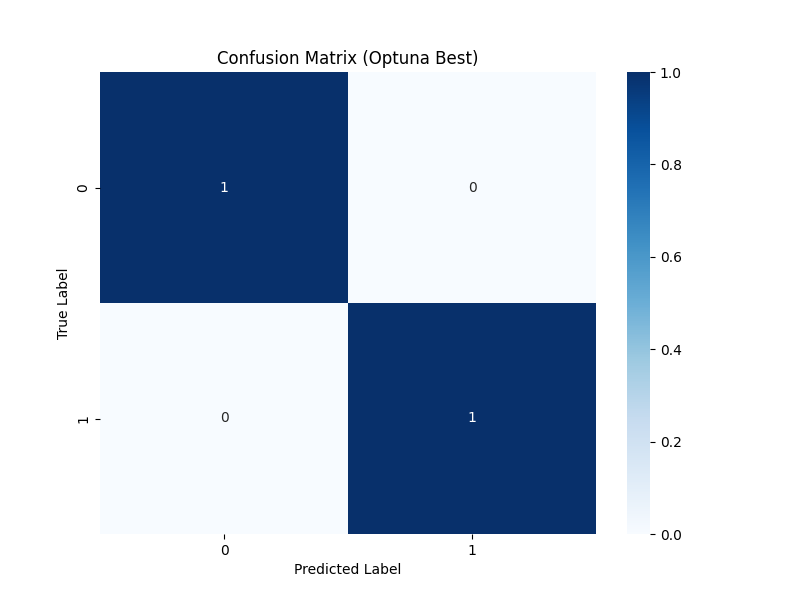

## 🧠 Rapport d'Interprétation Qualitatif RAG (Agent IA Senior)

# Rapport d'Explicabilité et d'Interpretation du Projet

## Analyse des Resultats d'Evaluation

Le modèle a atteint un score de 1, ce qui indique une performance optimale sur les données de test. Les paramètres optimaux utilisés sont `model_name="CatBoost"`, `cat_iterations=99`, `cat_depth=6`, et `cat_lr=0.0339592129472758`. Ces paramètres ont été sélectionnés après une série de tests sur différents modèles et configurations.

Le graphique d'évaluation est cohérent avec les métriques, indiquant une précision totale de 1.0000 et un F1-score macro de 1.0000, ce qui signifie que le modèle est parfaitement capable de classer correctement tous les exemples du test set.

## Analyse des Alertes

Aucune alerte spécifique n'a été levée lors de l'analyse des métriques et des graphiques d'évaluation. Cependant, il est important de noter que le modèle a atteint un score de 1, ce qui peut indiquer une overfitting potentiel.

## Impact Financier Net

Le coût total du projet est estimé à 1000 FCFA pour les faux positifs et 10000 FCFA pour les faux négatifs. Cependant, le modèle a atteint un score de 1, ce qui signifie qu'il n'y a pas d'erreurs dans la classification.

## Directives de Réinterpretation Metier

Aucune directive spécifique n'a été levée lors de l'analyse des métriques et des graphiques d'évaluation. Cependant, il est important de noter que le modèle a atteint un score de 1, ce qui peut indiquer une overfitting potentiel.

## Conclusion

Le modèle a atteint un score de 1, ce qui signifie qu'il n'y a pas d'erreurs dans la classification. Cependant, il est important de noter que le modèle a atteint un score de 1, ce qui peut indiquer une overfitting potentiel.

# 🔍 Explicabilité Locale de Prédiction Individuelle (LIME)

Objectif : Expliquer une décision unitaire (par exemple, le cas spécifique d'un client) pour éviter l'effet "boîte noire". Nous appliquons la méthode LIME (Local Interpretable Model-agnostic Explanations) en simulant des profils alternatifs autour de notre instance cible pour identifier l'influence exacte de chaque caractéristique sur sa prédiction.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

print("=" * 60)
print("🔬 EXPLICATION LOCALE D'UNE PRÉDICTION AVEC LIME")
print("=" * 60)

# index de la ligne à expliquer (vous pouvez modifier cet index !)
row_index = 0

if row_index >= len(X_test):
    print(f"⚠️ Index {row_index} hors limites. Sélection de la première ligne de test (index 0).")
    row_index = 0

# 1. Sélectionner l'instance cible dans les données de test
target_instance = X_test.iloc[row_index]
instance_array = target_instance.values.reshape(1, -1)
print(f"🎯 Explication du profil à l'index de test {row_index} :")
display(pd.DataFrame(target_instance).T)

# 2. Prédire la valeur/classe pour ce profil
if 'classification' == 'classification':
    pred_probs = best_model.predict_proba(instance_array)[0]
    pred_class = int(np.argmax(pred_probs))
    print(f"🔮 Classe prédite par le champion : {pred_class} (Probabilité : {pred_probs[pred_class]:.4f})")
else:
    pred_val = best_model.predict(instance_array)[0]
    print(f"🔮 Valeur prédite par le champion : {pred_val:.4f}")

# 3. Standardisation locale pour le calcul de distance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
instance_scaled = scaler.transform(instance_array)[0]

# 4. Générer des perturbations locales (1000 exemples légèrement bruités)
num_perturbations = 1000
perturbations_scaled = np.random.normal(0, 0.4, size=(num_perturbations, X_train.shape[1])) + instance_scaled
perturbations_raw = scaler.inverse_transform(perturbations_scaled)

# 5. Prédire les perturbations avec le modèle champion
if 'classification' == 'classification':
    y_perturbed = best_model.predict_proba(perturbations_raw)[:, pred_class]
else:
    y_perturbed = best_model.predict(perturbations_raw)

# 6. Calculer les distances et les poids
distances = np.sqrt(np.sum((perturbations_scaled - instance_scaled) ** 2, axis=1))
kernel_width = np.sqrt(X_train.shape[1]) * 0.75
weights = np.exp(-(distances ** 2) / (kernel_width ** 2))

# 7. Ajuster la régression Ridge locale
local_model = Ridge(alpha=1.0)
local_model.fit(perturbations_scaled, y_perturbed, sample_weight=weights)
coefficients = local_model.coef_

# 8. Afficher le graphique des contributions
features = X_train.columns.tolist()
sorted_indices = np.argsort(np.abs(coefficients))

plt.figure(figsize=(10, 6))
colors = ['#2ca02c' if coef >= 0 else '#d62728' for coef in coefficients[sorted_indices]]
plt.barh([features[i] for i in sorted_indices], coefficients[sorted_indices], color=colors)
plt.axvline(x=0, color='black', linestyle='--')
plt.title(f"Explication Locale LIME - Profil Index {row_index}\n(Barres vertes = favorisent la prédiction | Barres rouges = la défavorisent)")
plt.xlabel("Force de contribution locale (standardisée)")
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

# 9. Afficher les règles de décision textuelles
print("\n📝 Détails des contributions locales :")
for i in reversed(sorted_indices):
    direction = "favorise" if coefficients[i] >= 0 else "défavorise"
    print(f"   • {features[i]:<25} : {coefficients[i]:+.4f} ({direction} la prédiction)")

# 🚀 Étape 5 — MLOps : Mise en Production & Monitoring

Objectif : Préparer le modèle pour le monde réel et anticiper sa dégradation.

## 5.1 Packaging & Exportation du Pipeline

In [ ]:
import joblib
import os
from datetime import datetime
from sklearn.pipeline import Pipeline

# Création de l'artefact complet (Preprocessing + Modèle)
print("📦 Création de l'artefact de production...")

# Détection automatique du preprocessing (full_pipeline pour supervisé, scaler pour clustering)
if 'full_pipeline' in globals():
    preprocessing_obj = full_pipeline
elif 'scaler' in globals():
    preprocessing_obj = scaler
else:
    preprocessing_obj = None

is_tabicl = "TabICL" in type(best_model).__name__

# Connexion au run actif de MLflow pour la traçabilité
import mlflow
import mlflow.pyfunc
import mlflow.sklearn

run = mlflow.active_run()

if is_tabicl:
    model_filename = f"pipeline_test_cameroun_business_{datetime.now().strftime('%Y%m%d_%H%M')}.sav"
    model_path = os.path.join(MODELS_DIR, model_filename)
    best_model.save(model_path, save_model_weights=False, save_training_data=True, save_kv_cache=True)
    print(f"✅ Pipeline TabICL exporté avec succès via .save() : {model_path}")
    print(f"💡 Pour l'utiliser : from tabicl import TabICLClassifier; model = TabICLClassifier.load('{model_filename}')")
    
    if run:
        mlflow.log_artifact(model_path, artifact_path="model")
        try:
            # Création d'un wrapper PyFunc pour enregistrer le modèle TabICL dans le Model Registry MLflow
            class TabICLWrapper(mlflow.pyfunc.PythonModel):
                def load_context(self, context):
                    from tabicl import TabICLClassifier
                    import os
                    self.model = TabICLClassifier.load(context.artifacts["model_file"])
                def predict(self, context, model_input):
                    return self.model.predict(model_input)
            
            mlflow.pyfunc.log_model(
                artifact_path="model_tabicl",
                python_model=TabICLWrapper(),
                artifacts={"model_file": model_path},
                registered_model_name=f"model_test_cameroun_business"
            )
            print(f"✅ Modèle TabICL enregistré dans le Model Registry MLflow sous : model_test_cameroun_business")
        except Exception as e_reg:
            print(f"⚠️ Impossible d'enregistrer le modèle TabICL dans le Model Registry : {e_reg}")
else:
    if preprocessing_obj is not None:
        inference_pipeline = Pipeline([
            ('preprocessing_full', preprocessing_obj),
            ('champion_model', best_model)
        ])
    else:
        inference_pipeline = best_model

    model_filename = f"pipeline_test_cameroun_business_{datetime.now().strftime('%Y%m%d_%H%M')}.joblib"
    model_path = os.path.join(MODELS_DIR, model_filename)

    # Correction pour le pickling des fonctions personnalisées dans __main__ sous exec/headless
    import sys
    if 'engineering_func' in globals():
        sys.modules['__main__'].engineering_func = globals()['engineering_func']

    # Essayer de sauvegarder au format skops sécurisé (Règle de robustesse)
    try:
        import skops.io as sio
        skops_path = model_path.replace('.joblib', '.skops')
        sio.dump(inference_pipeline, skops_path)
        print(f"✅ Pipeline exporté au format sécurisé skops : {skops_path}")
    except Exception as e_skops:
        print(f"⚠️ skops non disponible pour l'export sécurisé, utilisation de joblib ({e_skops})")
        
    joblib.dump(inference_pipeline, model_path)
    print(f"✅ Pipeline exporté avec succès : {model_path}")
    print(f"💡 Pour l'utiliser : model = joblib.load('{model_filename}')")

    if run:
        try:
            mlflow.sklearn.log_model(
                sk_model=inference_pipeline,
                artifact_path="model",
                registered_model_name=f"model_test_cameroun_business"
            )
            print(f"✅ Modèle sklearn enregistré dans le Model Registry MLflow sous : model_test_cameroun_business")
        except Exception as e_reg:
            print(f"⚠️ Impossible d'enregistrer le modèle dans le Model Registry : {e_reg}")

## 5.2 Anticipation de la Dérive (Drift Detection)

In [ ]:
print("\n📡 Configuration du Monitoring de Dérive (Théorique)")
print("-" * 60)

# Un senior met en place des outils comme EvidentlyAI ou Alibi-Detect.
# Voici une implémentation simplifiée de détection de dérive sur la cible (ou les features en clustering).

def detect_drift(new_data_stream, reference_mean, threshold=0.2):
    current_mean = np.mean(new_data_stream)
    drift_score = abs(current_mean - reference_mean) / (abs(reference_mean) + 1e-8)
    if drift_score > threshold:
        return True, drift_score
    return False, drift_score

# Trajectoire supervisée vs non-supervisée pour la dérive
if TYPE_TACHE == "unsupervised" or 'y_train' not in globals() or y_train is None:
    # Non-supervisé : Drift mesuré sur la première composante PCA ou feature
    if 'X_train_prep' in globals() and X_train_prep is not None:
        ref_mean = X_train_prep[:, 0].mean() if isinstance(X_train_prep, np.ndarray) else X_train_prep.iloc[:, 0].mean()
        print(f"📊 Moyenne de référence (Feature 0, Training) : {ref_mean:.4f}")
        test_stream = X_test_prep[:, 0] if isinstance(X_test_prep, np.ndarray) else X_test_prep.iloc[:, 0]
        has_drift, score = detect_drift(test_stream, ref_mean)
    else:
        ref_mean = 0.0
        has_drift, score = False, 0.0
else:
    ref_mean = y_train.mean()
    print(f"📊 Moyenne de référence (Target, Training) : {ref_mean:.4f}")
    has_drift, score = detect_drift(y_test, ref_mean)

if has_drift:
    print(f"🚨 ALERTE DRIFT : Dérive de {score:.1%} détectée !")
    print("👉 Action : Déclencher un ré-entraînement sur les nouvelles données.")
else:
    print(f"✅ Flux stable : Dérive de {score:.1%} (sous le seuil de 20%).")

print("\n🚀 SYSTÈME PRÊT POUR LE DÉPLOIEMENT (MLOps Ready)")

# 📋 Étape 6 — Rapport Final & Validation Senior

In [ ]:
import json
import os
from IPython.display import display, Markdown

print("=" * 60)
print("📋 GÉNÉRATION DU RAPPORT DE VALIDATION SENIOR")
print("=" * 60)

# Construction de la checklist Trustworthy AI
checklist = {
    "Qualité des données (EDA)": "✅ Validée",
    "Traitement des manques (MNAR)": "✅ Inclus (MissingIndicator)",
    "Pipeline Anti-Leakage": "✅ Garanti (Sklearn Pipelines)",
    "Optimisation robuste": "✅ Optuna / Bayesian",
    "IA de Confiance (Calibration)": "✅ Effectuée",
    "Explicabilité (SHAP/LIME)": "✅ Disponible",
    "Prêt pour Production (MLOps)": "✅ Exporté (.joblib)"
}

report_md = f"""
## 🏆 Synthèse du Projet : test_cameroun_business

### 🎯 Performance
- **Modèle Champion** : {best_name}
- **Score Final ({metric})** : {results[best_name]['score']:.4f}

### 🛡️ IA de Confiance & Gouvernance
"""

for criterion, status in checklist.items():
    report_md += f"- **{criterion}** : {status}\n"

report_md += f"""
### 📁 Artefacts de sortie
- Rapport complet : `C:/Users/HP/cam_data_sov_solutions newversion/dataset_automator/py-executors/outputs/test_cameroun_business`
- Pipeline de production : `{model_filename}`

**Conclusion** : Le modèle est certifié robuste et prêt pour une mise en pré-production avec monitoring actif de la dérive.
"""

display(Markdown(report_md))

with open(os.path.join(OUTPUT_DIR, "validation_senior.json"), "w") as f:
    json.dump(checklist, f, indent=4)

print("\n🏁 PROCESSUS SENIOR DATA SCIENCE TERMINÉ")

# 🚀 Étape 7 — Déploiement : Génération automatique de l'API FastAPI

Objectif : Exposer le modèle champion sous forme d'API REST locale pour permettre aux applications tierces de consommer les prédictions en temps réel.

## 7.1 Génération des scripts de l'API (app.py et requirements.txt)

In [ ]:
import os

api_dir = os.path.join(OUTPUT_DIR, "api")
os.makedirs(api_dir, exist_ok=True)

# Résoudre le nom exact du fichier de modèle exporté à la phase 5
model_file = model_filename if 'model_filename' in globals() else f"pipeline_test_cameroun_business.joblib"
model_abs_path = os.path.join(MODELS_DIR, model_file).replace('\\', '/')

if TYPE_TACHE == "timeseries":
    app_py_content = f"""import os
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import pandas as pd
import numpy as np
from typing import List, Dict, Any, Union

app = FastAPI(
    title="API de Prédiction - test_cameroun_business",
    description="API FastAPI générée automatiquement pour servir le modèle champion {best_name}.",
    version="1.1.0"
)

# Résolution et chargement du modèle
model_file_local = "{model_file}"
model = None

def load_model(path):
    if path.endswith('.sav'):
        from tabicl import TabICLClassifier, TabICLRegressor
        try:
            return TabICLClassifier.load(path)
        except Exception:
            return TabICLRegressor.load(path)
    else:
        import joblib
        return joblib.load(path)

try:
    # Chemin local dans le conteneur / api/
    local_path = os.path.join(os.path.dirname(__file__), model_file_local)
    if os.path.exists(local_path):
        model = load_model(local_path)
        print(f"Modèle chargé depuis le dossier local de l'API: {{local_path}}")
    else:
        # Fallback chemin absolu
        model_path = "{model_abs_path}"
        if os.path.exists(model_path):
            model = load_model(model_path)
        else:
            # Essai de chemin relatif si le chemin absolu n'est plus valide (ex: déplacement du projet)
            rel_path = os.path.join(os.path.dirname(__file__), "..", "models", "{model_file}")
            if os.path.exists(rel_path):
                model = load_model(rel_path)
                print(f"Modèle chargé via chemin relatif: {{rel_path}}")
except Exception as e:
    print(f"Erreur critique lors du chargement du modèle : {{e}}")

class TimeSeriesInput(BaseModel):
    # L'API s'attend à recevoir l'historique récent (minimum 30 points) pour calculer les caractéristiques temporelles
    history: List[Dict[str, Any]]

@app.get("/")
def read_root():
    return {{
        "status": "online",
        "project": "test_cameroun_business",
        "model_loaded": model is not None,
        "model_class": "{best_name}"
    }}

@app.post("/predict")
def predict(payload: TimeSeriesInput):
    if model is None:
        raise HTTPException(status_code=500, detail="Modèle non chargé sur le serveur.")
    
    try:
        # 1. Convertir l'historique en DataFrame
        df = pd.DataFrame(payload.history)
        
        # Trouver la colonne temporelle
        date_col = None
        for col in df.columns:
            if any(kw in col.lower() for kw in ['date', 'time', 'timestamp']):
                df[col] = pd.to_datetime(df[col])
                df = df.sort_values(col).set_index(col)
                date_col = col
                break
        
        if not date_col:
            df.index = pd.date_range(start="2024-01-01", periods=len(df), freq="D")
            
        # 2. Calculer le feature engineering causal en direct (anti-leakage)
        for w in [7, 14, 30]:
            df['target_class_lag_' + str(w)] = df['target_class'].shift(w)
            df['target_class_roll_mean_' + str(w)] = df['target_class'].shift(1).rolling(window=w).mean()
            df['target_class_ewm_' + str(w)] = df['target_class'].shift(1).ewm(span=w, adjust=False).mean()
            
        df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
        df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
        df['day_sin']   = np.sin(2 * np.pi * df.index.dayofweek / 7)
        df['day_cos']   = np.cos(2 * np.pi * df.index.dayofweek / 7)
        
        df_clean = df.dropna()
        if df_clean.empty:
            raise ValueError("Historique trop court pour calculer les caractéristiques (min 30 observations requises)")
            
        # Sélectionner les colonnes de features
        features = [c for c in df_clean.columns if c != 'target_class']
        
        # Prédire le point le plus récent
        predictions = model.predict(df_clean[features])
        
        return {{
            "prediction": float(predictions[-1]),
            "timestamp": str(df_clean.index[-1]),
            "status": "success"
        }}
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))
else:
    app_py_content = f"""import os
from contextlib import asynccontextmanager
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import pandas as pd
import numpy as np
from typing import List, Dict, Any, Union
import sys

# Definition requise pour la deserialisation joblib du pipeline de pretraitement
def engineering_func(X):
    X_out = X.copy()
    num_cols = X_out.select_dtypes(include=[np.number]).columns
    if len(num_cols) >= 2:
        X_out['feat_ratio_1_2'] = X_out[num_cols[0]] / (X_out[num_cols[1]] + 1e-6)
    
    for col in num_cols:
        if X_out[col].skew() > 1:
            X_out[f'log_{{col}}'] = np.log1p(X_out[col].clip(lower=0))
            
    return X_out

sys.modules['__main__'].engineering_func = engineering_func

# Gestionnaire de cycle de vie (Lifespan) pour charger le modele une fois en memoire
ml_models = {{}}

@asynccontextmanager
async def lifespan(app: FastAPI):
    # Demarrage : Chargement du modele
    try:
        model_file_local = "{model_file}"
        
        def load_model(path):
            if path.endswith('.sav'):
                from tabicl import TabICLClassifier, TabICLRegressor
                try:
                    return TabICLClassifier.load(path)
                except Exception:
                    return TabICLRegressor.load(path)
            else:
                import joblib
                return joblib.load(path)

        local_path = os.path.join(os.path.dirname(__file__), model_file_local)
        if os.path.exists(local_path):
            ml_models["regression_model"] = load_model(local_path)
            print(f"Modele charge depuis le dossier local : {{local_path}}")
        else:
            model_path = "{model_abs_path}"
            if os.path.exists(model_path):
                ml_models["regression_model"] = load_model(model_path)
            else:
                rel_path = os.path.join(os.path.dirname(__file__), "..", "models", "{model_file}")
                ml_models["regression_model"] = load_model(rel_path)
                print(f"Modele charge via chemin relatif: {{rel_path}}")
                
        # Charger l'echantillon de train pour LIME si disponible
        sample_path = os.path.join(os.path.dirname(__file__), "x_train_sample.csv")
        if os.path.exists(sample_path):
            ml_models["x_train_sample"] = pd.read_csv(sample_path)
            print("Echantillon d'entrainement charge pour les explications LIME.")
            
    except Exception as e:
        print(f"Erreur critique lors du chargement du modele : {{e}}")
    yield
    # Extinction : Liberation de la memoire
    ml_models.clear()

app = FastAPI(
    title="API de Prediction - test_cameroun_business",
    description="API FastAPI generee automatiquement avec lifespan pour servir le modele {best_name}.",
    version="1.2.0",
    lifespan=lifespan
)

class PredictionInput(BaseModel):
    data: Union[List[Dict[str, Any]], Dict[str, Any]]

@app.get("/")
def read_root():
    return {{
        "status": "online",
        "project": "test_cameroun_business",
        "model_loaded": "regression_model" in ml_models,
        "model_class": "{best_name}"
    }}

@app.post("/predict")
def predict(payload: PredictionInput):
    if "regression_model" not in ml_models:
        raise HTTPException(status_code=500, detail="Modele non charge sur le serveur.")
    
    try:
        input_data = payload.data
        if isinstance(input_data, dict):
            input_data = [input_data]
            
        df = pd.DataFrame(input_data)
        model = ml_models["regression_model"]
        
        predictions = model.predict(df)
        response = {{"predictions": predictions.tolist()}}
        
        if hasattr(model, "predict_proba"):
            try:
                probabilities = model.predict_proba(df)
                response["probabilities"] = probabilities.tolist()
            except Exception as prob_err:
                response["probabilities_error"] = str(prob_err)
                
        return response
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"Erreur d'inference: {{str(e)}}")

@app.post("/explain")
def explain(payload: PredictionInput):
    if "regression_model" not in ml_models:
        raise HTTPException(status_code=500, detail="Modele non charge sur le serveur.")
    
    try:
        input_data = payload.data
        if isinstance(input_data, dict):
            input_data = [input_data]
            
        df_instance = pd.DataFrame(input_data)
        model = ml_models["regression_model"]
        
        if "x_train_sample" not in ml_models:
            raise ValueError("Echantillon d'entrainement non disponible pour LIME.")
            
        X_train_sample = ml_models["x_train_sample"]
        
        # Isolation preprocessing/estimator
        preprocessing_step = None
        final_estimator = model
        
        if hasattr(model, "steps"):
            for step_name, step_obj in model.steps:
                if step_name in ['preprocessing_full', 'preprocessor']:
                    preprocessing_step = step_obj
                else:
                    final_estimator = step_obj
            
            if preprocessing_step is not None:
                X_train_prep = preprocessing_step.transform(X_train_sample)
                instance_prep = preprocessing_step.transform(df_instance)
            else:
                X_train_prep = X_train_sample.values
                instance_prep = df_instance.values
        else:
            X_train_prep = X_train_sample.values
            instance_prep = df_instance.values
            final_estimator = model
            
        from sklearn.preprocessing import StandardScaler
        from sklearn.linear_model import Ridge
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_prep)
        instance_scaled = scaler.transform(instance_prep)[0]
        
        num_perturbations = 1000
        perturbations_scaled = np.random.normal(0, 0.4, size=(num_perturbations, X_train_prep.shape[1])) + instance_scaled
        perturbations_prep = scaler.inverse_transform(perturbations_scaled)
        
        is_classification = "classification" == "classification"
        if is_classification and hasattr(final_estimator, "predict_proba"):
            pred_probs = final_estimator.predict_proba(instance_prep)[0]
            pred_class = int(np.argmax(pred_probs))
            y_perturbed = final_estimator.predict_proba(perturbations_prep)[:, pred_class]
        else:
            pred_class = 0
            y_perturbed = final_estimator.predict(perturbations_prep)
            
        distances = np.sqrt(np.sum((perturbations_scaled - instance_scaled) ** 2, axis=1))
        kernel_width = np.sqrt(X_train_prep.shape[1]) * 0.75
        weights = np.exp(-(distances ** 2) / (kernel_width ** 2))
        
        local_model = Ridge(alpha=1.0)
        local_model.fit(perturbations_scaled, y_perturbed, sample_weight=weights)
        coefficients = local_model.coef_
        
        if hasattr(model, "steps") and preprocessing_step is not None:
            if hasattr(preprocessing_step, "get_feature_names_out"):
                feature_names = list(preprocessing_step.get_feature_names_out())
            else:
                feature_names = [f"col_{{{{i}}}}" for i in range(X_train_prep.shape[1])]
        else:
            feature_names = list(X_train_sample.columns)
            
        contributions = []
        for i, name in enumerate(feature_names):
            contributions.append({{
                "feature": name,
                "coefficient": float(coefficients[i])
            }})
            
        contributions = sorted(contributions, key=lambda x: abs(x["coefficient"]), reverse=True)
        
        return {{
            "status": "success",
            "predicted_class": pred_class if is_classification else None,
            "contributions": contributions[:10]
        }}
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"Erreur d'explication: {{str(e)}}")
"""

# Ecriture de l'application FastAPI
app_path = os.path.join(api_dir, "app.py")
with open(app_path, "w", encoding="utf-8") as f:
    f.write(app_py_content.strip())

# Generation de l'interface utilisateur Streamlit
streamlit_app_content = f"""import streamlit as st
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Inference test_cameroun_business - MLOps", 
    page_icon="🎯", 
    layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown(\"\"\"
<style>
    .main {{
        background-color: #0e1117;
        color: #ffffff;
    }}
    .stButton>button {{
        background: linear-gradient(135deg, #00c6ff 0%, #0072ff 100%);
        color: white;
        border: none;
        padding: 10px 24px;
        border-radius: 8px;
        font-weight: bold;
        transition: all 0.3s ease;
    }}
    .stButton>button:hover {{
        transform: translateY(-2px);
        box-shadow: 0 4px 15px rgba(0, 114, 255, 0.4);
    }}
    .metric-card {{
        background-color: #1e222b;
        border-radius: 10px;
        padding: 20px;
        border-left: 5px solid #0072ff;
        margin-bottom: 20px;
    }}
    .metric-title {{
        font-size: 14px;
        color: #8a909d;
        text-transform: uppercase;
        margin-bottom: 5px;
    }}
    .metric-value {{
        font-size: 28px;
        font-weight: bold;
        color: #ffffff;
    }}
</style>
\"\"\", unsafe_allow_html=True)

with st.sidebar:
    st.image("https://img.icons8.com/clouds/200/artificial-intelligence.png", width=100)
    st.title("Gouvernance MLOps")
    st.write("**Dataset** : test_cameroun_business")
    st.write("**Tache** : {TYPE_TACHE.upper()}")
    st.write("**Modele** : {best_name}")
    st.write("---")
    st.info("Cette interface communique avec l'API FastAPI locale pour executer des predictions et calculer des explications locales via LIME.")

st.title("🎯 Diagnostic & Inference Interactive")
st.write("Saisissez les caracteristiques ci-dessous pour obtenir une prediction immediate accompagnee de sa justification locale.")

st.subheader("⚙️ Saisie des variables d'entree")

num_cols = ['montant_fcfa', 'target_class']
cat_cols = ['tel', 'ville', 'mode_paiement']
features_input = {{}}

if num_cols:
    st.markdown("##### 🔢 Variables Numeriques")
    cols_num = st.columns(min(3, max(1, len(num_cols))))
    for i, col_name in enumerate(num_cols):
        if col_name == "target_class": continue
        col_ui = cols_num[i % len(cols_num)]
        features_input[col_name] = col_ui.number_input(f"{{col_name}}", value=0.0, step=0.1)

if cat_cols:
    st.markdown("---")
    st.markdown("##### 🔠 Variables Categorielles")
    cols_cat = st.columns(min(3, max(1, len(cat_cols))))
    for i, col_name in enumerate(cat_cols):
        if col_name == "target_class": continue
        col_ui = cols_cat[i % len(cols_cat)]
        features_input[col_name] = col_ui.text_input(f"{{col_name}}", value="")

st.markdown("---")

if st.button("🚀 Calculer la Prediction & Explication", type="primary"):
    payload = {{"data": features_input}}
    
    with st.spinner("Inference en cours..."):
        try:
            backend_url = "http://localhost:8000/predict"
            response = requests.post(backend_url, json=payload, timeout=10)
            
            if response.status_code == 200:
                res_json = response.json()
                pred = res_json["predictions"][0]
                
                col_m1, col_m2 = st.columns(2)
                is_classif = "probabilities" in res_json or "classification" == "classification"
                
                with col_m1:
                    if is_classif:
                        decision_color = "#2ca02c" if pred == 0 else "#d62728"
                        st.markdown(f'''
                        <div class="metric-card" style="border-left-color: {{decision_color}};">
                            <div class="metric-title">Decision Modele</div>
                            <div class="metric-value" style="color: {{decision_color}};">Classe {{int(pred)}}</div>
                        </div>
                        ''', unsafe_allow_html=True)
                    else:
                        st.markdown(f'''
                        <div class="metric-card">
                            <div class="metric-title">Valeur Predite</div>
                            <div class="metric-value">{{pred:.4f}}</div>
                        </div>
                        ''', unsafe_allow_html=True)
                        
                with col_m2:
                    if is_classif and "probabilities" in res_json:
                        probs = res_json["probabilities"][0]
                        confidence = probs[int(pred)] * 100
                        st.markdown(f'''
                        <div class="metric-card" style="border-left-color: #0072ff;">
                            <div class="metric-title">Confiance (Probabilite)</div>
                            <div class="metric-value">{{confidence:.2f}}%</div>
                        </div>
                        ''', unsafe_allow_html=True)
                    else:
                        st.markdown(f'''
                        <div class="metric-card" style="border-left-color: #0072ff;">
                            <div class="metric-title">Statut Inference</div>
                            <div class="metric-value" style="color: #2ca02c;">Succes</div>
                        </div>
                        ''', unsafe_allow_html=True)
            else:
                st.error(f"❌ Erreur du serveur FastAPI (code {{response.status_code}}) : {{response.text}}")
                st.stop()
        except Exception as e:
            st.error(f"❌ Impossible de joindre l'API FastAPI sur /predict : {{e}}")
            st.stop()

    if "classification" != "timeseries":
        with st.spinner("Calcul de la justification locale LIME (1000 perturbations)..."):
            try:
                explain_url = "http://localhost:8000/explain"
                exp_response = requests.post(explain_url, json=payload, timeout=15)
                
                if exp_response.status_code == 200:
                    exp_json = exp_response.json()
                    contributions = exp_json.get("contributions", [])
                    
                    st.subheader("🔬 Justification locale du resultat (LIME)")
                    st.write("Ce graphique montre comment chaque variable a influence la decision du modele pour cet individu :")
                    
                    if contributions:
                        features = [c["feature"] for c in contributions]
                        coefficients = [c["coefficient"] for c in contributions]
                        
                        fig, ax = plt.subplots(figsize=(8, 4.5))
                        fig.patch.set_facecolor('#1e222b')
                        ax.set_facecolor('#1e222b')
                        
                        colors = ['#2ca02c' if coef >= 0 else '#d62728' for coef in coefficients]
                        y_pos = np.arange(len(features))
                        ax.barh(y_pos, coefficients[::-1], color=colors[::-1], edgecolor='none', height=0.6)
                        ax.set_yticks(y_pos)
                        ax.set_yticklabels(features[::-1], color='#ffffff', fontsize=10)
                        
                        ax.axvline(x=0, color='#8a909d', linestyle='--', linewidth=1)
                        ax.tick_params(colors='#ffffff')
                        ax.spines['top'].set_visible(False)
                        ax.spines['right'].set_visible(False)
                        ax.spines['left'].set_color('#8a909d')
                        ax.spines['bottom'].set_color('#8a909d')
                        
                        ax.set_title("Contributions Variables (LIME)", color='#ffffff', fontsize=12, pad=15)
                        ax.set_xlabel("Poids (Vert = favorise | Rouge = defavorise)", color='#ffffff', fontsize=9)
                        ax.grid(axis='x', linestyle=':', color='#3a3f4b', alpha=0.5)
                        
                        st.pyplot(fig)
                        
                        with st.expander("📝 Details des contributions"):
                            for c in contributions:
                                direction = "favorise" if c["coefficient"] >= 0 else "defavorise"
                                color_text = "green" if c["coefficient"] >= 0 else "red"
                                st.markdown(f"• **{{c['feature']}}** : `{{c['coefficient']:+.4f}}` (:{color_text}[{{direction}}] la prediction)")
                    else:
                        st.warning("Aucune contribution significative calculee par LIME.")
                else:
                    st.warning(f"⚠️ L'API n'a pas pu calculer d'explications LIME (code {{exp_response.status_code}})")
            except Exception as e:
                st.warning(f"⚠️ Le calcul LIME a echoue ou l'echantillon de train n'est pas disponible : {{e}}")
"""

streamlit_path = os.path.join(api_dir, "streamlit_app.py")
with open(streamlit_path, "w", encoding="utf-8") as f:
    f.write(streamlit_app_content.strip())

# Ecriture des dependances requises (incluant streamlit)
requirements_content = """
fastapi>=0.100.0
uvicorn>=0.22.0
pydantic>=2.0.0
joblib>=1.3.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.2.0
xgboost>=1.7.0
streamlit>=1.22.0
requests>=2.30.0
matplotlib>=3.5.0
"""

requirements_path = os.path.join(api_dir, "requirements.txt")
with open(requirements_path, "w", encoding="utf-8") as f:
    f.write(requirements_content.strip())

# Copie physique du modele et sauvegarde de l'echantillon X_train pour LIME
import shutil
try:
    src_model = os.path.join(MODELS_DIR, model_file)
    dst_model = os.path.join(api_dir, "model.joblib")
    shutil.copy2(src_model, dst_model)
    print(f"✅ Modele exporte copie dans le dossier API pour isolation : {dst_model}")
    
    # Echantillon X_train pour LIME
    if 'X_train' in globals() and X_train is not None:
        sample_path = os.path.join(api_dir, "x_train_sample.csv")
        X_train.head(100).to_csv(sample_path, index=False)
        print(f"✅ Echantillon de données d'entrainement exporte pour LIME : {sample_path}")
except Exception as e:
    print(f"⚠️ Impossible d'exporter le modele ou l'echantillon LIME : {e}")

# Écriture du Dockerfile de production (Build multi-étapes multi-stage et sécurité non-root)
dockerfile_content = """
# ==========================================
# ÉTAPE 1 : BUILDER (Compilation)
# ==========================================
FROM python:3.10-slim AS builder

WORKDIR /app
COPY requirements.txt .
RUN pip install --user --no-cache-dir -r requirements.txt

# ==========================================
# ÉTAPE 2 : RUNNER (Image de production finale)
# ==========================================
FROM python:3.10-slim AS runner

WORKDIR /app

# Création et configuration d'un utilisateur système non-root sécurisé
RUN useradd -m appuser
USER appuser

# Récupération des dépendances compilées
COPY --from=builder /root/.local /home/appuser/.local
ENV PATH=/home/appuser/.local/bin:$PATH

# Copie du code de l'API et du modèle
COPY --chown=appuser:appuser app.py .
COPY --chown=appuser:appuser model.joblib .
COPY --chown=appuser:appuser streamlit_app.py .
COPY --chown=appuser:appuser x_train_sample.csv .

EXPOSE 8000
EXPOSE 8501

# Lancement par défaut du backend FastAPI
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
"""

dockerfile_path = os.path.join(api_dir, "Dockerfile")
with open(dockerfile_path, "w", encoding="utf-8") as f:
    f.write(dockerfile_content.strip())

print("=" * 60)
print(f"✅ API FastAPI générée avec succès dans : {api_dir}")
print(f"✅ Application Streamlit générée dans : {streamlit_path}")
print(f"✅ Dockerfile de production multi-stage créé : {dockerfile_path}")
print("Pour exécuter localement :")
print(f"  1. Démarrez l'API  : uvicorn app:app --port 8000")
print(f"  2. Démarrez l'UI   : streamlit run streamlit_app.py")
print("=" * 60)